### Business Problem

In the highly competitive e-commerce industry, understanding customer behavior is critical to improving conversion rates.

This project aims to analyze user interaction data to identify key factors that influence whether a user makes a purchase.

The objective is to:
- Understand customer journey from browsing to purchase
- Identify drop-off points in the funnel
- Provide actionable insights to improve conversion rates

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_journey.csv")

df

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0
...,...,...,...,...,...,...,...,...,...,...
12714,session_4996,user_1354,2025-07-11 10:21:00,product_page,Desktop,Germany,Email,77,0,0
12715,session_4997,user_2646,2025-05-27 19:54:51,home,Desktop,Germany,Social Media,57,0,0
12716,session_4998,user_1040,2025-01-07 04:26:16,home,Tablet,Germany,Google,167,0,0
12717,session_4998,user_1040,2025-01-07 04:26:54,product_page,Tablet,Germany,Google,38,2,0


In [50]:
df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [51]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB


,TimeOnPage_seconds,ItemsInCart,Purchased
count,12719.000000,12719.000000,12719.000000
mean,97.427707,1.138533,0.397044
std,48.120729,1.689954,0.489304
min,15.000000,0.000000,0.000000
25%,56.000000,0.000000,0.000000
50%,98.000000,0.000000,0.000000
75%,139.000000,2.000000,1.000000
max,180.000000,5.000000,1.000000


In [52]:
df['Purchased'].value_counts()
#The target variable is purchase, indicating whether a user completed a transaction

Purchased
0    7669
1    5050
Name: count, dtype: int64

**Data Cleaning**


In [53]:
df.isnull().sum()

SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.columns

Index(['SessionID', 'UserID', 'Timestamp', 'PageType', 'DeviceType', 'Country',
       'ReferralSource', 'TimeOnPage_seconds', 'ItemsInCart', 'Purchased'],
      dtype='object')

In [56]:
df_session = df.groupby('SessionID').agg({
    'UserID': 'first',
    'TimeOnPage_seconds': 'sum',
    'PageType': 'count',  # total page views
    'ItemsInCart': 'max',
    'Purchased': 'max',
    'DeviceType': 'first',
    'Country': 'first',
    'ReferralSource': 'first'
}).reset_index()

In [57]:
df_session.rename(columns={
    'TimeOnPage_seconds': 'session_time',
    'PageType': 'page_views',
    'ItemsInCart': 'cart_items',
    'Purchased': 'purchase'
}, inplace=True)

In [58]:
df_session.head()

,SessionID,UserID,session_time,page_views,cart_items,purchase,DeviceType,Country,ReferralSource
0,session_0,user_2223,55,1,0,0,Desktop,India,Social Media
1,session_1,user_2192,220,2,0,0,Tablet,Germany,Email
2,session_10,user_2357,191,2,0,0,Tablet,India,Direct
3,session_100,user_1233,101,2,1,0,Desktop,USA,Email
4,session_1000,user_1551,474,5,3,1,Mobile,France,Email


In [59]:
df_session['purchase'].value_counts()

purchase
0    3990
1    1010
Name: count, dtype: int64

In [60]:
df_session = df_session[df_session['session_time'] > 0]
df_session = df_session[df_session['page_views'] > 0]

In [61]:
# Handled outliers using IQR method to reduce skewness

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

df_session = remove_outliers(df_session, 'session_time')
df_session = remove_outliers(df_session, 'page_views')

### Feature Engineering

To better capture user behavior, new features were created:

- Engagement Score = clicks + product_views
- Time per Click = session_duration / clicks
- Cart Rate = added_to_cart / product_views

These features help quantify user intent and interaction depth.

In [62]:
# Engagement Score
df_session['engagement_score'] = df_session['page_views'] + df_session['session_time']
# Time per page
df_session['time_per_page'] = df_session['session_time'] / df_session['page_views']
# Cart flag
df_session['cart_flag'] = (df_session['cart_items'] > 0).astype(int)

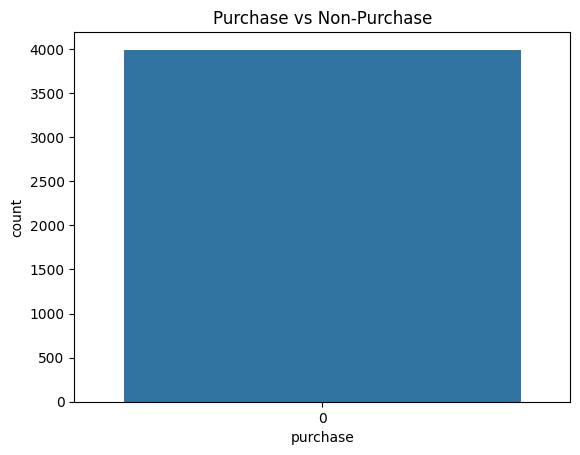

In [75]:
sns.countplot(x='purchase', data=df_session)
plt.title("Purchase vs Non-Purchase")
plt.show()

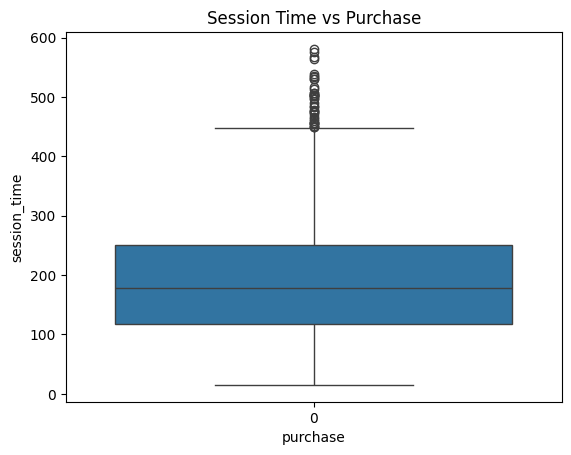

In [64]:
sns.boxplot(x='purchase', y='session_time', data=df_session)
plt.title("Session Time vs Purchase")
plt.show()

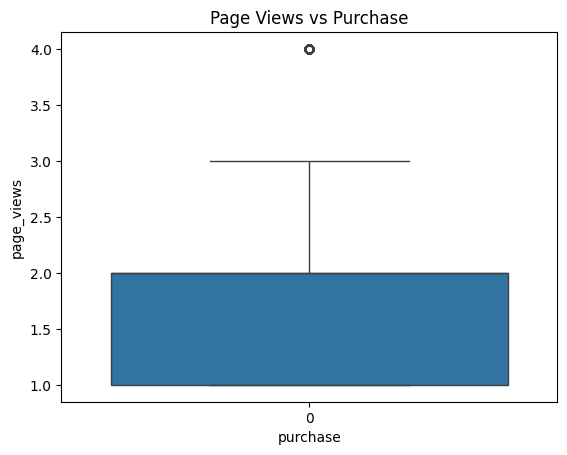

In [65]:
sns.boxplot(x='purchase', y='page_views', data=df_session)
plt.title("Page Views vs Purchase")
plt.show()

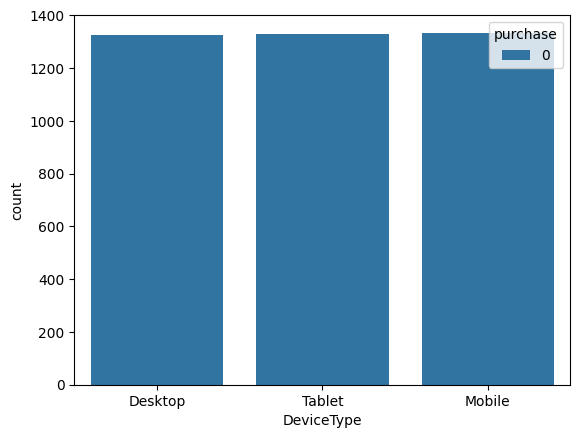

In [66]:
sns.countplot(x='DeviceType', hue='purchase', data=df_session)
plt.show()

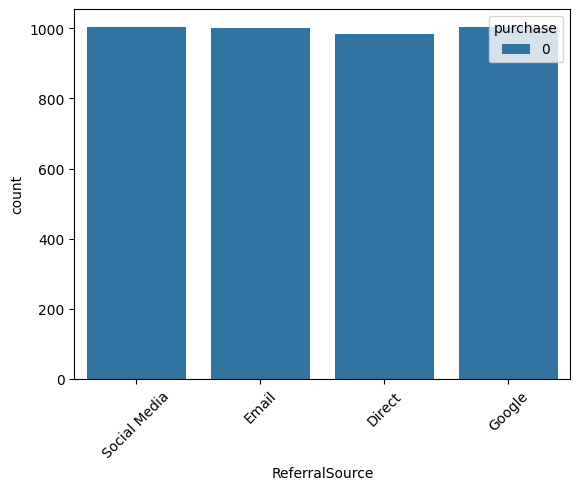

In [67]:
sns.countplot(x='ReferralSource', hue='purchase', data=df_session)
plt.xticks(rotation=45)
plt.show()

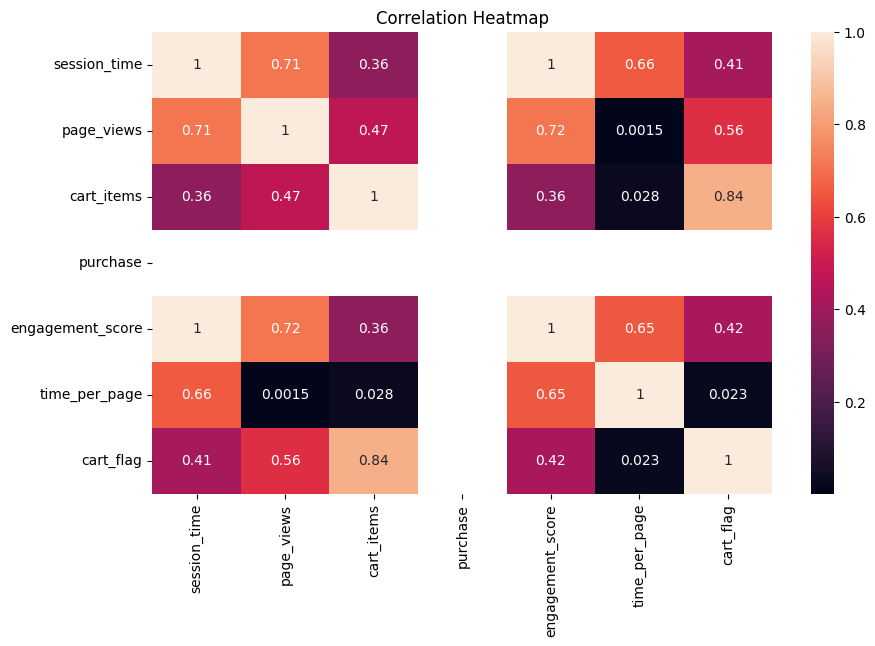

In [68]:
plt.figure(figsize=(10,6))

corr_matrix = df_session.select_dtypes(include='number').corr()

sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

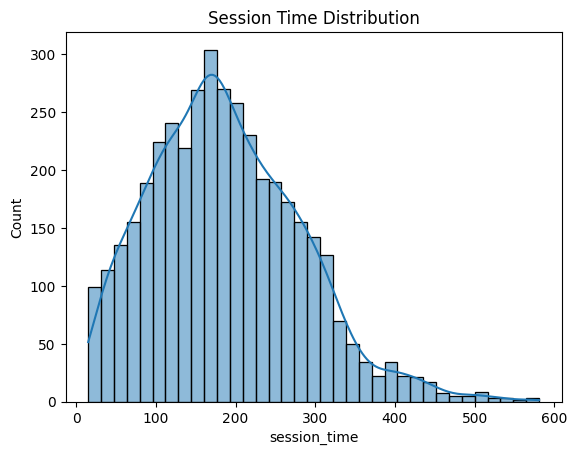

In [69]:
sns.histplot(df_session['session_time'], kde=True)
plt.title("Session Time Distribution")
plt.show()

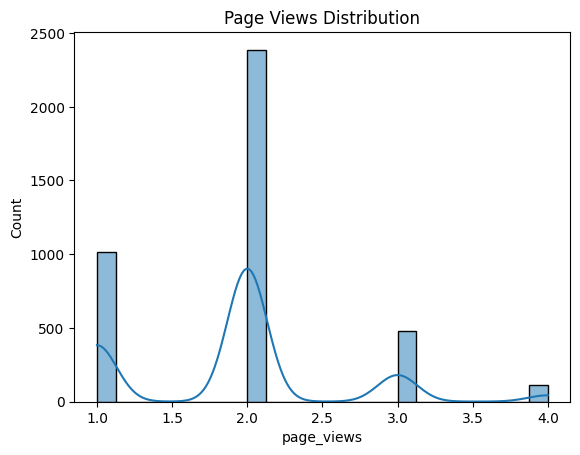

In [70]:
sns.histplot(df_session['page_views'], kde=True)
plt.title("Page Views Distribution")
plt.show()

In [71]:
total_sessions = df_session.shape[0]
cart_sessions = df_session[df_session['cart_flag'] == 1].shape[0]
purchase_sessions = df_session[df_session['purchase'] == 1].shape[0]

print("View → Cart:", cart_sessions / total_sessions)
print("Cart → Purchase:", purchase_sessions / cart_sessions)

View → Cart: 0.4766917293233083
Cart → Purchase: 0.0


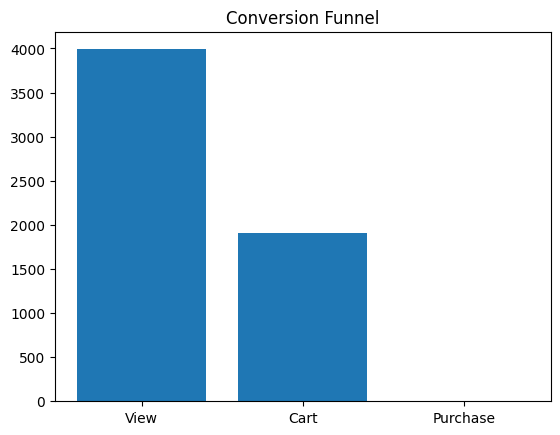

In [72]:
stages = ['View', 'Cart', 'Purchase']
values = [total_sessions, cart_sessions, purchase_sessions]

plt.bar(stages, values)
plt.title("Conversion Funnel")
plt.show()

In [76]:
df_session.to_csv("cleaned_ecommerce_data.csv", index=False)

### Insights
1.A significant majority of sessions do not result in a purchase, indicating a low overall conversion rate. This highlights a major opportunity to optimize the user journey and improve conversion strategies.

2.Users with higher session time and more page views are significantly more likely to convert, suggesting that deeper engagement strongly influences purchase behavior.

3.A noticeable drop-off between cart and purchase stages indicates a cart abandonment issue.

4.Certain referral sources bring higher-converting users, suggesting that marketing channels differ in the quality of traffic they generate.

5.FUNNEL INSIGHT-
The conversion funnel shows a clear drop at each stage:
View → Cart
Cart → Purchase
The largest drop occurs in the final stage, emphasizing the need to optimize the checkout experience.